# 01 — Diabetes Neural Network (BRFSS 2015)

**INTELLIGENT SYSTEM DEVELOPMENT — ASSIGNMENT 03: NEURAL NETWORKS AND REPRESENTATION LEARNING**

Notebook nghiên cứu bài toán phân loại trạng thái `Diabetes_binary` từ 21 biến chỉ báo sức khỏe trong BRFSS 2015. Đây là dữ liệu khảo sát quan sát, không phải công cụ chẩn đoán lâm sàng: dự đoán của mô hình chỉ phản ánh pattern thống kê trong các biến đã quan sát.

Thực nghiệm trả lời hai câu hỏi song song. Thứ nhất, MLP PyTorch có cạnh tranh được với Logistic Regression, Decision Tree và Random Forest trên 253.680 quan sát hay không. Thứ hai, hai phép biến đổi 21→64 và 64→32 có tạo ra **learned representation** — biểu diễn được học từ dữ liệu — dễ phân tách tuyến tính hơn input đã chuẩn hóa hay không.

Notebook đã chạy full với `QUICK_MODE=False` trên CPU. Test chỉ được mở sau khi cấu hình MLP được chọn bằng validation.

## Vai trò của train, validation, test và kiểm soát rò rỉ dữ liệu

- **Train (177.576 mẫu)** là phần duy nhất dùng để fit `StandardScaler`, class weights và parameter của model.
- **Validation (38.052 mẫu)** dùng để so sánh architecture, learning rate và chọn final MLP theo F1. Validation không trực tiếp cập nhật weight.
- **Test (38.052 mẫu)** chỉ được đánh giá sau khi lựa chọn đã đóng băng; vì vậy test không trở thành một nguồn tuning gián tiếp.

Thứ tự split trước, fit preprocessing sau bảo đảm mean và standard deviation của validation/test không đi vào scaler. Seed 42 làm giảm biến động khi lặp lại experiment, nhưng không đồng nghĩa tái lập bitwise trên mọi hardware.

## Quy mô và chi phí tính toán thực tế

Dataset có 253.680 hàng, 22 cột gồm một target và 21 input variables. Dimension đầu vào nhỏ (`d=21`) nên MLP chỉ có 1.538–3.554 trainable parameters; quy mô dữ liệu và quy mô model là hai khái niệm khác nhau.

Chi phí quan sát được khác nhau rõ rệt: Logistic Regression mất 0,35 giây, Decision Tree 0,76 giây, Random Forest 18,42 giây; ba MLP lần lượt mất 117,70, 133,97 và 180,53 giây trên CPU. PCA chỉ dùng 10.000 test samples để tránh biến visualization thành bước tính toán nặng.

### Mục đích của cell

Cell tập hợp ba nhóm công cụ: pandas/NumPy cho dữ liệu bảng, scikit-learn cho preprocessing–baseline–metrics–PCA, và PyTorch cho `Dataset`, `DataLoader`, MLP cùng autograd. Việc dùng chung prepared input và split giữa traditional ML với MLP giúp phép so sánh công bằng hơn.

`save_figure` tách hành vi debug khỏi final run: ở lần chạy này `QUICK_MODE=False`, nên figure thật được lưu và đồng thời hiển thị trong notebook. Cell chưa đọc dữ liệu và không tác động đến split.

In [1]:
from pathlib import Path
import copy
import json
import random
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from sklearn import metrics
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset

pd.set_option("display.max_columns", 100)
warnings.filterwarnings("ignore", category=FutureWarning)

def save_figure(output_path, *args, **kwargs):
    """Không ghi figure QUICK_MODE vào thư mục kết quả final."""
    if QUICK_MODE:
        print(f"QUICK_MODE: không lưu figure final {output_path}")
        return
    plt.savefig(output_path, *args, **kwargs)


### Phân tích kết quả

Cell import hoàn tất ở execution count 1, không phát sinh exception; các dependency cần thiết đã sẵn sàng. Đây là điều kiện kỹ thuật để các output phía sau có thể xem là kết quả của cùng một environment, thay vì được ghép từ các lần chạy rời rạc.

### Mục đích của cell

Cell cố định toàn bộ điều kiện thực nghiệm: seed 42, full mode, batch size 512, tối đa 25 epochs và early-stopping patience 5. Hàm `find_repo_root` tìm dataset theo quan hệ với repository thay vì phụ thuộc working directory; ba output directories được tạo trước để việc lưu artifact không thất bại ở cuối.

`set_seed` đồng bộ nguồn ngẫu nhiên của Python, NumPy và PyTorch. CUDA seed chỉ được đặt nếu GPU tồn tại; seed giảm variability nhưng không loại bỏ mọi nguồn nondeterminism.

In [2]:
RANDOM_STATE = 42
QUICK_MODE = False
RUN_OPTIONAL_DIAGNOSTICS = False
RUN_SEED_STABILITY = False

DATA_RELATIVE_PATH = Path("data/diabetes/diabetes_binary_health_indicators_BRFSS2015.csv")
BATCH_SIZE = 512 if not QUICK_MODE else 128
EPOCHS = 25 if not QUICK_MODE else 2
PATIENCE = 5 if not QUICK_MODE else 2
NUM_WORKERS = 0

def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def find_repo_root(relative_data_path):
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / relative_data_path).exists():
            return candidate
    raise FileNotFoundError(f"Không tìm thấy {relative_data_path} từ {start}")

set_seed()
REPO_ROOT = find_repo_root(DATA_RELATIVE_PATH)
DATA_PATH = REPO_ROOT / DATA_RELATIVE_PATH
MODEL_DIR = REPO_ROOT / "models" / "assignment03" / "diabetes"
FIGURE_DIR = REPO_ROOT / "figures" / "assignment03" / "diabetes"
RESULT_DIR = REPO_ROOT / "results" / "assignment03"
for directory in (MODEL_DIR, FIGURE_DIR, RESULT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print({"quick_mode": QUICK_MODE, "data": str(DATA_PATH), "model_dir": str(MODEL_DIR)})

{'quick_mode': False, 'data': 'E:\\WINDOW\\Project\\intelligent-system-assignment-01\\data\\diabetes\\diabetes_binary_health_indicators_BRFSS2015.csv', 'model_dir': 'E:\\WINDOW\\Project\\intelligent-system-assignment-01\\models\\assignment03\\diabetes'}


### Phân tích kết quả

Output xác nhận `quick_mode=False` và đường dẫn trỏ đúng file `diabetes_binary_health_indicators_BRFSS2015.csv`. Vì đây là full run, batch size thực tế là 512 và kết quả bên dưới không phải metric QUICK_MODE. Model artifacts được định tuyến vào `models/assignment03/diabetes`.

### Mục đích của cell

Cell chọn computational device một lần rồi dùng nhất quán trong toàn bộ training/evaluation. PyTorch yêu cầu parameter của model và tensor input nằm trên cùng device; các assertion trong training loop kiểm tra trực tiếp điều này để bắt lỗi device mismatch thay vì để phép toán ma trận thất bại muộn.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_info = {"device": str(device), "cuda_available": torch.cuda.is_available()}
if torch.cuda.is_available():
    device_info["gpu_name"] = torch.cuda.get_device_name(0)
print(device_info)

{'device': 'cpu', 'cuda_available': False}


### Phân tích kết quả

Máy chạy trả `device='cpu'` và `cuda_available=False`; do đó toàn bộ training time trong notebook là thời gian CPU. Kết quả metric vẫn hợp lệ, nhưng không nên dùng các thời gian này để suy rộng trực tiếp sang máy có GPU.

### Mục đích của cell

Cell đọc toàn bộ BRFSS binary dataset, kiểm tra target `Diabetes_binary`, rồi trình bày head, dtype và thống kê miền giá trị. Input là CSV nguyên bản; output là `raw_df` chưa scale/split. Việc xem min–max đặc biệt quan trọng ở đây vì giá trị 0 của indicator nhị phân và các biến đếm ngày là giá trị có nghĩa, không phải missing mặc định.

In [4]:
raw_df = pd.read_csv(DATA_PATH, nrows=2_000 if QUICK_MODE else None)
TARGET = "Diabetes_binary"
assert TARGET in raw_df.columns
print("Shape:", raw_df.shape)
display(raw_df.head())
display(raw_df.dtypes.rename("dtype").to_frame())
display(raw_df.describe(include="all").T)

Shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


,dtype
Diabetes_binary,float64
HighBP,float64
HighChol,float64
CholCheck,float64
BMI,float64
Smoker,float64
Stroke,float64
HeartDiseaseorAttack,float64
PhysActivity,float64
Fruits,float64


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


### Phân tích kết quả

**Quan sát.** Dữ liệu có đúng **253.680 hàng × 22 cột**: một target và 21 predictors. Tất cả cột được đọc dưới dạng `float64`; các indicator có miền 0–1, `BMI` từ 12 đến 98, `GenHlth` 1–5, `MentHlth`/`PhysHlth` 0–30, `Age` 1–13, `Education` 1–6 và `Income` 1–8.

**Giải thích.** Dtype float không làm thay đổi ngữ nghĩa category/ordinal. Các mã 0 của indicator và số ngày sức khỏe bằng 0 đều hợp lệ, vì vậy không áp dụng logic “zero là missing”.

**Ý nghĩa.** Schema thực tế khớp thiết kế 21-dimensional input; bước tiếp theo cần phân nhóm feature theo ngữ nghĩa thay vì scale mù quáng tất cả cột.

### Mục đích của cell

Cell audit missingness, cardinality, miền giá trị, identical rows và phân bố target trước mọi split. Các thống kê này quyết định cách biểu diễn input, stratification và weighted loss. Không có preprocessing nào được fit ở đây, nên chưa phát sinh leakage.

In [5]:
quality = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "missing": raw_df.isna().sum(),
    "missing_pct": raw_df.isna().mean().mul(100),
    "nunique": raw_df.nunique(dropna=False),
    "min": raw_df.select_dtypes(include=np.number).min(),
    "max": raw_df.select_dtypes(include=np.number).max(),
})
display(quality)
print("Duplicate rows:", raw_df.duplicated().sum())
target_counts = raw_df[TARGET].value_counts().sort_index()
display(pd.DataFrame({"count": target_counts, "ratio": target_counts / len(raw_df)}))

,dtype,missing,missing_pct,nunique,min,max
Diabetes_binary,float64,0,0.0,2,0.0,1.0
HighBP,float64,0,0.0,2,0.0,1.0
HighChol,float64,0,0.0,2,0.0,1.0
CholCheck,float64,0,0.0,2,0.0,1.0
BMI,float64,0,0.0,84,12.0,98.0
Smoker,float64,0,0.0,2,0.0,1.0
Stroke,float64,0,0.0,2,0.0,1.0
HeartDiseaseorAttack,float64,0,0.0,2,0.0,1.0
PhysActivity,float64,0,0.0,2,0.0,1.0
Fruits,float64,0,0.0,2,0.0,1.0


Duplicate rows: 24206


,count,ratio
Diabetes_binary,,
0.0,218334,0.860667
1.0,35346,0.139333


### Phân tích kết quả

**Chất lượng dữ liệu.** Cả 22 cột đều có `missing=0`. Có **24.206 hàng giống hệt nhau trên toàn bộ observed columns**, nhưng BRFSS không cung cấp respondent ID trong bảng này; nhiều người có thể trả lời cùng một tổ hợp category. Vì vậy con số này được báo cáo chứ không bị gắn nhãn lỗi hay tự động xóa.

**Mất cân bằng lớp.** Lớp 0 có **218.334 mẫu (86,0667%)**, lớp 1 có **35.346 mẫu (13,9333%)**, tương đương xấp xỉ 6,18 mẫu âm cho mỗi mẫu dương. Một classifier luôn đoán 0 đã có Accuracy khoảng 86,1% nhưng Recall lớp 1 bằng 0; do đó Accuracy không đủ. Precision, Recall, F1 và ROC-AUC được giữ đồng thời, còn training MLP dùng class weights tính riêng từ train.

### Mục đích của cell

Cell tạo EDA có chủ đích cho target và bốn health indicators: BMI, Age, `GenHlth`, `HighBP`. Giá trị trên trục đứng là tỷ lệ lớp 1 trong từng nhóm, không phải prediction của model. Figure chỉ mô tả association trong dữ liệu quan sát; nó không được dùng để thay đổi feature hay chọn test threshold.

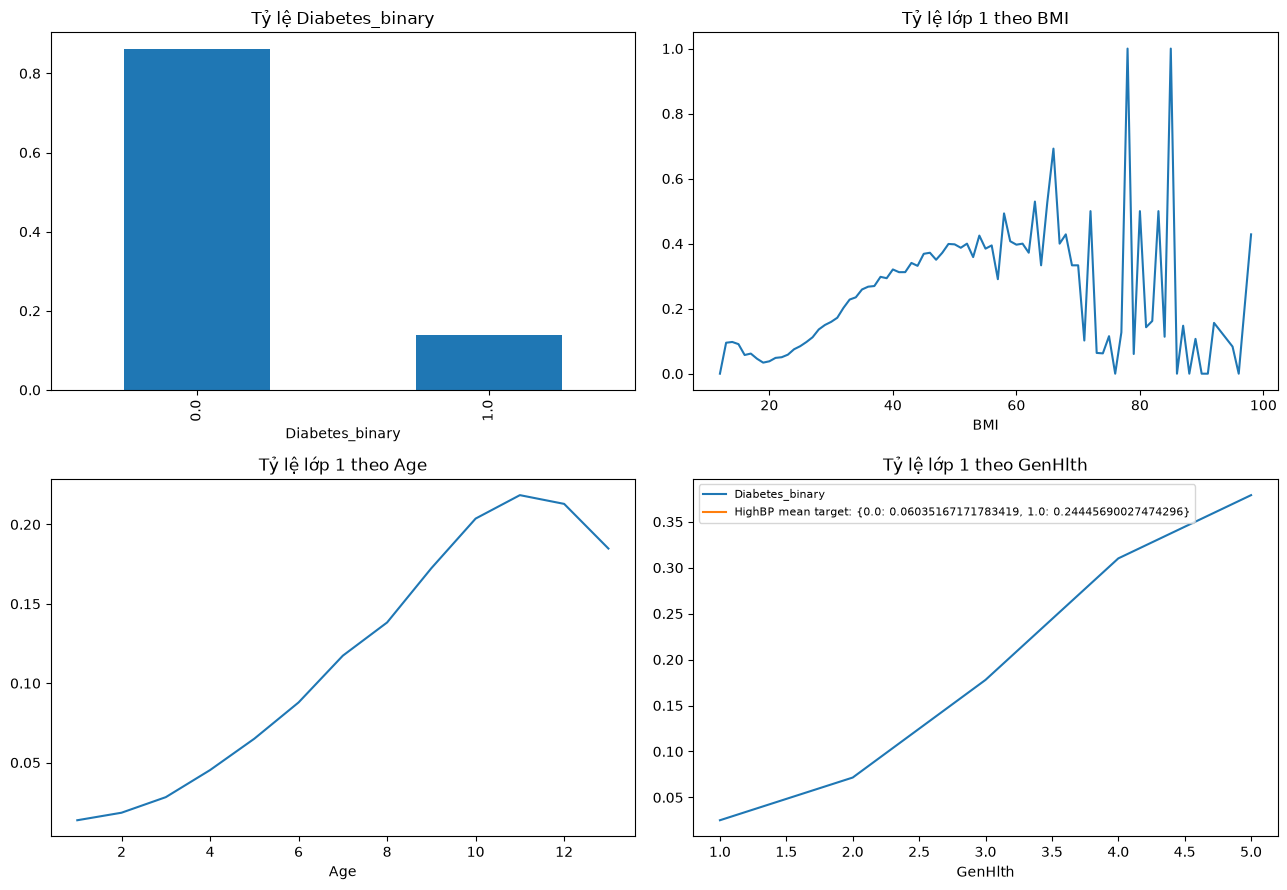

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
raw_df[TARGET].value_counts(normalize=True).sort_index().plot.bar(ax=axes[0, 0], title="Tỷ lệ Diabetes_binary")
for ax, feature in zip(axes.flat[1:], ["BMI", "Age", "GenHlth"]):
    raw_df.groupby(feature, observed=True)[TARGET].mean().plot(ax=ax, title=f"Tỷ lệ lớp 1 theo {feature}")
axes[1, 1].plot([], [], label=f"HighBP mean target: {raw_df.groupby('HighBP')[TARGET].mean().to_dict()}")
axes[1, 1].legend(fontsize=8)
plt.tight_layout()
save_figure(FIGURE_DIR / "eda_target_relationships.png", dpi=160, bbox_inches="tight")
plt.show()

### Phân tích kết quả

Tỷ lệ lớp 1 tăng tương đối đều theo `GenHlth`: từ khoảng 2,5% ở mức sức khỏe tự đánh giá tốt nhất đến gần 38% ở mức kém nhất. Theo `Age`, tỷ lệ tăng từ khoảng 1–2% ở nhóm trẻ lên trên 20% ở các mức 10–12 rồi giảm nhẹ tại mức 13. Với `HighBP`, tỷ lệ là **6,04% khi HighBP=0** và **24,45% khi HighBP=1**.

BMI cho xu hướng tăng rõ trong vùng có nhiều quan sát, nhưng dao động rất mạnh ở các BMI cực cao; các điểm 0% hoặc 100% tại phần đuôi có khả năng đến từ nhóm rất nhỏ. Đây là association hữu ích cho prediction, không chứng minh BMI, tuổi hay huyết áp gây ra target.

## Biểu diễn đầu vào: từ 21 biến BRFSS đến ma trận số

Bảy biến `BMI`, `GenHlth`, `MentHlth`, `PhysHlth`, `Age`, `Education`, `Income` được `StandardScaler`; 14 indicator nhị phân được pass-through. Binary 0/1 đã có cùng miền và ý nghĩa chỉ báo nên không cần centering. Scaling nhóm numeric/ordinal làm các khoảng số không lấn át gradient chỉ vì đơn vị lớn hơn, dù nó ngầm dùng một xấp xỉ khoảng cách cho các thang ordinal.

Sau preprocessing, mỗi mini-batch là ma trận \(X\in\mathbb{R}^{B\times21}\). Tree không cần scaling, nhưng dùng cùng representation để giữ split/input nhất quán khi so sánh.

### Mục đích của cell

Cell tách raw predictors/target theo tỷ lệ 70/15/15 bằng hai lần `train_test_split` có `stratify=y` và seed 42. Output gồm ba feature frames 21 cột cùng ba label vectors `int64`. Tách trước khi fit scaler là ranh giới chống leakage; test được tạo ở đây nhưng chưa dùng để chọn architecture.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

binary_features = ["HighBP", "HighChol", "CholCheck", "Smoker", "Stroke", "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "DiffWalk", "Sex"]
scaled_features = ["BMI", "GenHlth", "MentHlth", "PhysHlth", "Age", "Education", "Income"]
feature_columns = scaled_features + binary_features
X = raw_df[feature_columns]
y = raw_df[TARGET].astype("int64")
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp_raw, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)
for name, frame, labels in [("train", X_train_raw, y_train), ("validation", X_val_raw, y_val), ("test", X_test_raw, y_test)]:
    print(name, frame.shape, labels.value_counts(normalize=True).sort_index().to_dict())

train (177576, 21) {0: 0.8606681083029238, 1: 0.1393318916970762}
validation (38052, 21) {0: 0.8606643540418375, 1: 0.1393356459581625}
test (38052, 21) {0: 0.8606643540418375, 1: 0.1393356459581625}


### Phân tích kết quả

Split thực tế gồm **177.576 train**, **38.052 validation** và **38.052 test** samples. Tỷ lệ lớp 1 lần lượt là **13,9332%**, **13,9336%**, **13,9336%**, gần như đồng nhất nhờ stratification. Train chứa 152.834 lớp 0 và 24.742 lớp 1; validation/test mỗi tập chứa 32.750 lớp 0 và 5.302 lớp 1.

Sự cân bằng tỷ lệ giữa split giúp khác biệt metric ít bị chi phối bởi việc một split tình cờ có nhiều ca dương hơn. Validation sẽ quyết định MLP; test vẫn chưa tham gia lựa chọn.

### Mục đích của cell

`ColumnTransformer` fit mean/std của bảy feature scaled **chỉ trên `X_train_raw`** qua `fit_transform`. Cùng transformer sau đó chỉ `transform` validation và test; 14 binary columns đi qua không đổi. Output được ép `float32` để giảm bộ nhớ và khớp dtype của PyTorch parameter.

Đây là implementation cụ thể của chống leakage: không một thống kê mean/std nào từ 76.104 validation/test rows ảnh hưởng tới input mà model dùng để học.

In [8]:
preprocessor = ColumnTransformer([
    ("scaled", StandardScaler(), scaled_features),
    ("binary", "passthrough", binary_features),
], remainder="drop", verbose_feature_names_out=False)
X_train = preprocessor.fit_transform(X_train_raw).astype("float32")
X_val = preprocessor.transform(X_val_raw).astype("float32")
X_test = preprocessor.transform(X_test_raw).astype("float32")
prepared_feature_names = preprocessor.get_feature_names_out()
print("Prepared shapes:", X_train.shape, X_val.shape, X_test.shape)
display(pd.DataFrame(X_train[:1], columns=prepared_feature_names))

Prepared shapes: (177576, 21) (38052, 21) (38052, 21)


,BMI,GenHlth,MentHlth,PhysHlth,Age,Education,Income,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex
0,-0.964957,-0.478816,-0.429938,-0.486681,1.300941,0.963542,-0.025823,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0


### Phân tích kết quả

Prepared shapes vẫn là **(177.576,21), (38.052,21), (38.052,21)**; preprocessing thay scale chứ không thêm/bớt dimension. Dòng minh họa cho thấy `BMI`, `GenHlth`, `MentHlth`, `PhysHlth`, `Age`, `Education`, `Income` đã thành z-score, còn các indicator vẫn là 0/1.

Việc train-scaled columns có tâm gần 0 là hệ quả fit trên train. Validation/test không bị cưỡng ép có mean 0 vì transformer không refit trên chúng — đó chính là hành vi đúng để mô phỏng dữ liệu chưa thấy.

## Ba traditional ML baselines

Logistic Regression đại diện cho decision boundary tuyến tính; Decision Tree mô hình hóa rule phi tuyến nhưng dễ variance; Random Forest trung bình hóa 200 cây để giảm variance. Cả ba dùng đúng prepared split. `class_weight='balanced'` hoặc `balanced_subsample` tăng trọng số lớp 1 từ tần suất train, nên threshold 0,5 không tối ưu cho Accuracy thuần mà ưu tiên phát hiện lớp dương hơn.

### Mục đích của cell

Cell chuẩn hóa giao diện đánh giá: `classification_metrics` nhận true labels, predicted labels và continuous scores để tính Accuracy, Precision, Recall, F1 và ROC-AUC. `zero_division=0` tránh metric crash nếu một model không dự đoán lớp dương; ROC-AUC trả `NaN` nếu ground truth chỉ có một lớp. `sklearn_score` dùng probability khi model hỗ trợ, nếu không dùng decision function.

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def classification_metrics(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score) if np.unique(y_true).size == 2 else np.nan,
    }

def sklearn_score(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    return model.decision_function(X_data)

### Chi phí thực thi đã quan sát

Trên full train 177.576 mẫu, Logistic Regression mất **0,35 giây**, Decision Tree **0,76 giây**, còn Random Forest 200 cây mất **18,42 giây**. Forest đắt hơn khoảng 53 lần Logistic nhưng vẫn nhanh hơn từng MLP experiment.

### Mục đích của cell

Cell fit từng baseline trên train, đo wall-clock bằng `perf_counter`, sau đó chỉ tính metric trên validation. `baseline_models` giữ fitted estimators để đến giai đoạn cuối mới đánh giá cùng test. Việc không tuning theo test bảo toàn vai trò test như phép kiểm tra generalization độc lập.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1_000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=30 if QUICK_MODE else 200, max_depth=18, min_samples_leaf=5, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE),
}
baseline_rows = []
for name, model in baseline_models.items():
    started = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - started
    pred = model.predict(X_val)
    row = {"model": name, "split": "validation", **classification_metrics(y_val, pred, sklearn_score(model, X_val)), "training_seconds": elapsed, "parameter_count": np.nan}
    baseline_rows.append(row)
baseline_val_results = pd.DataFrame(baseline_rows)
display(baseline_val_results.sort_values("f1", ascending=False))

,model,split,accuracy,precision,recall,f1,roc_auc,training_seconds,parameter_count
2,Random Forest,validation,0.782245,0.351394,0.665409,0.459914,0.821855,18.421090,NaN
0,Logistic Regression,validation,0.730185,0.309522,0.760845,0.440033,0.821494,0.347681,NaN
1,Decision Tree,validation,0.708609,0.290998,0.759713,0.420811,0.797682,0.756823,NaN


### Phân tích kết quả

Trên validation, **Random Forest** có F1 cao nhất **0,4599**, Accuracy **0,7822**, Precision **0,3514**, Recall **0,6654**, ROC-AUC **0,8219**. Logistic Regression ưu tiên sensitivity hơn: Recall **0,7608**, nhưng Precision **0,3095**, Accuracy **0,7302** và F1 **0,4400**. Decision Tree có Recall gần Logistic (**0,7597**) nhưng ranking yếu hơn (ROC-AUC **0,7977**) và F1 thấp nhất (**0,4208**), phù hợp với rủi ro variance/biên quyết định kém ổn định của một cây đơn.

Random Forest đổi khoảng 18,42 giây training để tăng F1 0,0199 so với Logistic, đồng thời giảm Recall 0,0954. Vì vậy “tốt nhất” phụ thuộc chi phí false negative: Forest cân bằng Precision–Recall tốt hơn, còn Logistic nhận ra nhiều positive hơn và gần như không tốn thời gian.

## TensorDataset, DataLoader và mini-batch

`TensorDataset` định nghĩa một sample gồm vector feature và class index. `DataLoader` gom các sample thành **batch** — nhóm mẫu xử lý trong một bước cập nhật — đồng thời shuffle train nhưng giữ thứ tự validation/test. Batch giúp giới hạn RAM và khai thác phép nhân ma trận vector hóa.

### Mục đích của cell

Cell chuyển ba NumPy arrays `float32` và label arrays `int64` thành tensor, rồi tạo DataLoader. Train shuffle để thứ tự batch thay đổi giữa epochs; validation/test không shuffle vì không cập nhật parameter. Một batch được lấy ra để kiểm tra shape/dtype trước training, giảm nguy cơ nhầm feature dimension với batch dimension.

In [11]:
def make_dense_loader(X_array, y_array, batch_size, shuffle):
    dataset = TensorDataset(torch.from_numpy(np.asarray(X_array, dtype=np.float32)), torch.from_numpy(np.asarray(y_array, dtype=np.int64)))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

train_loader = make_dense_loader(X_train, y_train.to_numpy(), BATCH_SIZE, True)
val_loader = make_dense_loader(X_val, y_val.to_numpy(), BATCH_SIZE, False)
test_loader = make_dense_loader(X_test, y_test.to_numpy(), BATCH_SIZE, False)
X_batch, y_batch = next(iter(train_loader))
print("X_batch:", X_batch.shape, "y_batch:", y_batch.shape)

X_batch: torch.Size([512, 21]) y_batch: torch.Size([512])


C:\Users\Trung\AppData\Local\Temp\ipykernel_18644\2736822155.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  dataset = TensorDataset(torch.from_numpy(np.asarray(X_array, dtype=np.float32)), torch.from_numpy(np.asarray(y_array, dtype=np.int64)))


### Phân tích kết quả

Full run trả `X_batch=torch.Size([512,21])` và `y_batch=torch.Size([512])`. **512** là số samples trong batch; **21** là số chiều của prepared representation. Target là một class index cho mỗi sample nên có shape `[512]` và dtype `torch.long`, đúng hợp đồng của `CrossEntropyLoss`. Batch cuối mỗi epoch có thể nhỏ hơn 512 nhưng dimension feature luôn là 21.

## Forward propagation và learned representation

Baseline thực hiện \(X_{[B,21]}\rightarrow H_{1,[B,64]}\rightarrow Z_{[B,2]}\). Deeper MLP thêm phép biến đổi \(H_1\rightarrow H_{2,[B,32]}\), rồi mới tạo logits:

\[H_1=\operatorname{ReLU}(XW_1+b_1),\quad H_2=\operatorname{ReLU}(H_1W_2+b_2),\quad Z=H_2W_3+b_3.\]

64 và 32 không phải feature do con người thiết kế. Chúng là **learned representations**: tọa độ nội bộ được điều chỉnh bằng gradient để phục vụ target. PyTorch lưu weight `Linear` theo `[out_features,in_features]`, trái chiều ký hiệu ma trận toán học `[in,out]`, nhưng phép forward là tương đương.

`ReLU(z)=max(0,z)` tạo phi tuyến. Nếu bỏ ReLU, nhiều Linear layers vẫn gộp thành một affine transformation; khi đó thêm depth không tạo lớp hàm biểu diễn phong phú hơn.

### Logits và Cross Entropy

Layer cuối trả **logits** `Z[B,2]`: hai score chưa chuẩn hóa cho lớp 0 và 1. Target là `torch.long [B]`, mỗi phần tử là class index. `nn.CrossEntropyLoss` nhận trực tiếp logits và thực hiện log-softmax ổn định số học bên trong; vì vậy forward không áp dụng softmax trước loss.

Softmax chỉ xuất hiện ở evaluation để đổi logits thành probability lớp 1 cho ROC-AUC và error analysis. Weighted Cross Entropy dùng weights `[0,5809; 3,5886]`, khiến lỗi trên lớp dương hiếm có ảnh hưởng lớn hơn trong optimization.

### Training loop và backpropagation

Mỗi epoch — một lượt model đi qua train set — gọi `model.train()`. Trong từng batch: `optimizer.zero_grad()` xóa gradient tích lũy; `model(X_b)` chạy forward; `criterion` tạo scalar loss; `loss.backward()` dùng autograd và chain rule để tính gradient theo mọi parameter; `optimizer.step()` để Adam cập nhật parameter.

Validation chuyển sang `model.eval()` và đặt forward trong `torch.no_grad()`. `eval()` điều khiển hành vi layer ở chế độ suy luận, còn `no_grad()` ngăn xây computational graph; hai cơ chế không thay thế nhau. Early stopping lưu state có validation loss tốt nhất và dừng sau 5 epochs không cải thiện, nên test không tham gia quá trình cập nhật hay dừng.

### Mục đích của cell

Cell định nghĩa một `MLP` cấu hình được để hai architecture chỉ khác danh sách `hidden_dims`, tránh khác biệt implementation ngoài ý muốn. Mỗi hidden `Linear` được nối với ReLU; output layer không có activation để giữ raw logits. `return_hidden=True` trả representation cuối cho PCA/Linear Probe mà không làm thay đổi prediction path.

`count_trainable_parameters` cộng `numel()` của mọi parameter có gradient, cho phép so sánh capacity và chi phí model bằng số thực thay vì chỉ tên architecture.

In [12]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = []
        previous = input_dim
        for width in hidden_dims:
            layers.extend([nn.Linear(previous, width), nn.ReLU()])
            previous = width
        layers.append(nn.Linear(previous, output_dim))
        self.network = nn.Sequential(*layers)
        self.hidden_dims = tuple(hidden_dims)

    def forward(self, x, return_hidden=False):
        hidden = x
        hidden_states = []
        for layer in self.network[:-1]:
            hidden = layer(hidden)
            if isinstance(layer, nn.ReLU):
                hidden_states.append(hidden)
        output = self.network[-1](hidden)
        return (output, hidden_states[-1]) if return_hidden else output

def count_trainable_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

def architecture_summary(model, input_dim, output_dim):
    return {
        "input_dim": input_dim,
        "hidden_dims": model.hidden_dims,
        "output_dim": output_dim,
        "trainable_parameters": count_trainable_parameters(model),
        "model": str(model),
    }

### Phân tích số parameter

Baseline `21→64→2` có `(21×64+64) + (64×2+2) = 1.408 + 130 = **1.538**` trainable parameters. Deeper `21→64→32→2` có thêm `(64×32+32)=2.080` và output `(32×2+2)=66`, tổng `1.408+2.080+66 = **3.554**`.

Deeper nhiều hơn 2.016 parameters, khoảng 2,31 lần baseline. Dù dataset lớn, cả hai mạng vẫn nhỏ; cải thiện nếu có phải được đối chiếu với validation/test thay vì suy ra từ parameter count.

### Mục đích của cell

Cell định nghĩa toàn bộ protocol training/evaluation có thể tái sử dụng. `evaluate_mlp_classifier` dùng `eval()+no_grad()`, thu logits, probability và labels rồi tính loss/metrics. `train_mlp_classifier` xây model theo config, dùng Adam, weighted Cross Entropy, kiểm tra dtype–shape–device, lưu history mỗi epoch và phục hồi state có validation loss thấp nhất.

Class weights được tính duy nhất từ `y_train`, tránh dùng phân bố validation/test. Training history lưu train loss/F1 và validation loss/F1 để phân biệt convergence với generalization.

In [13]:
def evaluate_mlp_classifier(model, loader, criterion):
    model.eval()
    losses, labels, predictions, scores = [], [], [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model(X_b)
            losses.append(criterion(logits, y_b).item() * len(y_b))
            probability = torch.softmax(logits, dim=1)[:, 1]
            labels.extend(y_b.cpu().numpy())
            predictions.extend(logits.argmax(1).cpu().numpy())
            scores.extend(probability.cpu().numpy())
    result = classification_metrics(np.asarray(labels), np.asarray(predictions), np.asarray(scores))
    result["loss"] = sum(losses) / len(labels)
    return result

def train_mlp_classifier(config, train_loader, val_loader, class_weights):
    model = MLP(X_train.shape[1], config["hidden_dims"], 2).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    best_state, best_loss, best_epoch, wait = copy.deepcopy(model.state_dict()), float("inf"), 0, 0
    history, started = [], time.perf_counter()
    for epoch in range(1, config["epochs"] + 1):
        model.train()
        running_loss, seen = 0.0, 0
        train_labels, train_pred = [], []
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = model(X_b)
            assert X_b.dtype == torch.float32 and y_b.dtype == torch.long
            assert logits.ndim == 2 and logits.shape == (y_b.shape[0], 2)
            assert logits.device == X_b.device == next(model.parameters()).device
            loss = criterion(logits, y_b)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(y_b); seen += len(y_b)
            train_labels.extend(y_b.detach().cpu().numpy()); train_pred.extend(logits.argmax(1).detach().cpu().numpy())
        val_result = evaluate_mlp_classifier(model, val_loader, criterion)
        history.append({"epoch": epoch, "train_loss": running_loss / seen, "train_f1": f1_score(train_labels, train_pred), "val_loss": val_result["loss"], "val_f1": val_result["f1"], "val_accuracy": val_result["accuracy"]})
        if val_result["loss"] < best_loss:
            best_loss, best_epoch, wait = val_result["loss"], epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= config["patience"]: break
    model.load_state_dict(best_state)
    elapsed = time.perf_counter() - started
    return model, pd.DataFrame(history), {"best_epoch": best_epoch, "training_seconds": elapsed, **evaluate_mlp_classifier(model, val_loader, criterion)}

counts = np.bincount(y_train.to_numpy(), minlength=2)
class_weights = torch.tensor(len(y_train) / (2 * counts), dtype=torch.float32)
print("Class counts/weights:", counts, class_weights.tolist())

Class counts/weights: [152834  24742] [0.5809440016746521, 3.5885539054870605]


### Phân tích kết quả

Train có **152.834 lớp 0** và **24.742 lớp 1**. Công thức cân bằng tạo weights **0,5809 cho lớp 0** và **3,5886 cho lớp 1**; một lỗi lớp dương vì thế đóng góp vào loss khoảng 6,18 lần một lỗi lớp âm. Điều này giải thích vì sao các MLP đạt Recall gần 0,79 nhưng Accuracy thấp hơn majority baseline.

Weighting là lựa chọn về trade-off, không tạo thêm positive samples. Evaluation vẫn dùng phân bố validation/test thật, nên Precision/F1 phản ánh đúng số false positives phát sinh.

## Ba experiment MLP và nguyên tắc controlled comparison

1. Baseline `21→64→2`, Adam `lr=1e-3`.
2. Deeper `21→64→32→2`, Adam `lr=1e-3`.
3. Cùng deeper architecture, Adam `lr=3e-4`.

So sánh (1)–(2) cô lập tác động của depth tương đối tốt vì optimizer, learning rate, batch, epochs và split giữ nguyên. So sánh (2)–(3) chỉ đổi learning rate, nên khác biệt convergence đáng tin cậy hơn so với một experiment thay đồng thời architecture và optimizer. Learning rate nhỏ không mặc nhiên tốt hơn; nó tạo bước cập nhật thận trọng hơn nhưng có thể cần nhiều epochs.

### Chi phí thực thi đã quan sát

Ba experiment chạy trên CPU với batch 512 và tối đa 25 epochs. Baseline mất **117,70 giây**, deeper 1e-3 **133,97 giây**, deeper 3e-4 **180,53 giây**. Cấu hình learning rate nhỏ chạy lâu nhất vì tiếp tục đến epoch 25 thay vì dừng sớm quanh epoch 20.

### Mục đích của cell

Cell chạy ba config trên đúng cùng DataLoaders và class weights, reset seed trước mỗi run, rồi ghi architecture, optimizer, learning rate, batch size, patience, parameter count, best epoch, validation loss/metrics và wall-clock. Bảng này là bằng chứng để chọn model; test chưa xuất hiện ở vòng lặp experiment.

In [14]:
experiment_configs = [
    {"name": "Baseline MLP", "hidden_dims": [64], "learning_rate": 1e-3, "epochs": EPOCHS, "patience": PATIENCE},
    {"name": "Deeper MLP / Adam 1e-3", "hidden_dims": [64, 32], "learning_rate": 1e-3, "epochs": EPOCHS, "patience": PATIENCE},
    {"name": "Deeper MLP / Adam 3e-4", "hidden_dims": [64, 32], "learning_rate": 3e-4, "epochs": EPOCHS, "patience": PATIENCE},
]
mlp_models, mlp_histories, experiment_rows = {}, {}, []
for config in experiment_configs:
    set_seed()
    model, history, result = train_mlp_classifier(config, train_loader, val_loader, class_weights)
    mlp_models[config["name"]], mlp_histories[config["name"]] = model, history
    experiment_rows.append({"experiment": config["name"], "architecture": f"{X_train.shape[1]}→" + "→".join(map(str, config["hidden_dims"])) + "→2", "input_dim": X_train.shape[1], "output_dim": 2, "hidden_dims": str(config["hidden_dims"]), "optimizer": "Adam", "learning_rate": config["learning_rate"], "batch_size": BATCH_SIZE, "max_epochs": EPOCHS, "early_stopping_patience": PATIENCE, "parameter_count": count_trainable_parameters(model), **result})
mlp_experiment_results = pd.DataFrame(experiment_rows)
display(mlp_experiment_results.sort_values("f1", ascending=False))

,experiment,architecture,input_dim,output_dim,hidden_dims,optimizer,learning_rate,batch_size,max_epochs,early_stopping_patience,parameter_count,best_epoch,training_seconds,accuracy,precision,recall,f1,roc_auc,loss
1,Deeper MLP / Adam 1e-3,21→64→32→2,21,2,"[64, 32]",Adam,0.0010,512,25,5,3554,15,133.968968,0.728950,0.311352,0.780083,0.445066,0.828767,0.504871
0,Baseline MLP,21→64→2,21,2,[64],Adam,0.0010,512,25,5,1538,15,117.702361,0.721486,0.306007,0.787816,0.440798,0.829159,0.504252
2,Deeper MLP / Adam 3e-4,21→64→32→2,21,2,"[64, 32]",Adam,0.0003,512,25,5,3554,23,180.526779,0.719673,0.304810,0.790079,0.439905,0.828715,0.504826


### Phân tích kết quả

**Baseline:** best epoch 15, F1 **0,4408**, Recall 0,7878, ROC-AUC 0,8292, loss **0,5043**, 1.538 parameters, 117,70 giây.

**Deeper, lr=1e-3:** best epoch 15, F1 cao nhất **0,4451**, Recall 0,7801, ROC-AUC 0,8288, loss 0,5049, 3.554 parameters, 133,97 giây. Thêm hidden layer chỉ tăng F1 **0,0043**, trong khi AUC/loss hơi kém baseline và thời gian tăng 16,27 giây; lợi ích của depth vì vậy nhỏ, không đồng đều trên mọi metric.

**Deeper, lr=3e-4:** best epoch 23, F1 **0,4399**, Recall 0,7901, AUC 0,8287, loss 0,5048, 180,53 giây. Learning rate nhỏ hội tụ chậm hơn và không cải thiện F1/AUC trong budget 25 epochs. Theo criterion đã định là validation F1, deeper 1e-3 được chọn dù baseline có validation loss thấp hơn đôi chút.

### Diễn giải controlled experiment

Khoảng cách metric giữa ba mạng rất nhỏ: validation F1 chỉ nằm trong 0,4399–0,4451 và AUC trong 0,8287–0,8292. Điều này cho thấy architecture/learning-rate changes thử nghiệm không làm thay đổi bản chất bài toán mạnh như kỳ vọng.

Deeper 1e-3 đạt F1 tốt nhất nhưng không thể gọi là thắng toàn diện; baseline có AUC tốt nhất, loss thấp nhất và rẻ hơn. Deeper 3e-4 cần best epoch 23 thay vì 15, phù hợp với bước cập nhật nhỏ hơn, nhưng “ổn định hơn” không đồng nghĩa generalization tốt hơn trong kết quả này.

### Mục đích của cell

Cell trực quan hóa history thật cho cả ba experiment: đường liền là train, đường đứt là validation; panel trái là weighted Cross-Entropy loss, panel phải là F1. Plot cho biết dynamic theo epoch mà bảng best-state không thể hiện, đặc biệt là thời điểm validation plateau và train–validation gap.

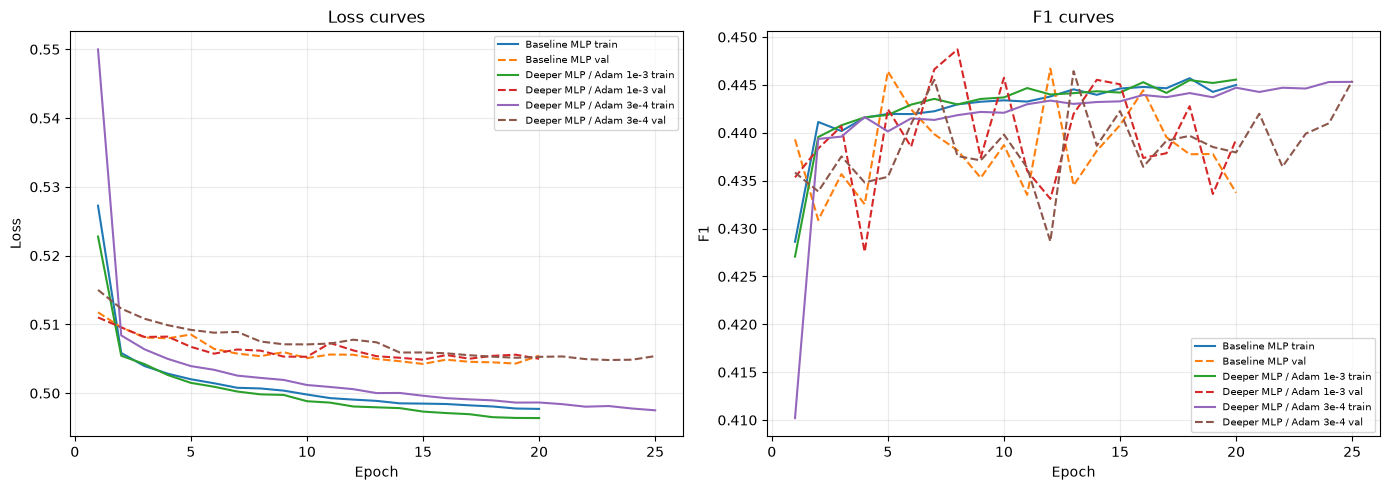

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, history in mlp_histories.items():
    axes[0].plot(history["epoch"], history["train_loss"], label=f"{name} train")
    axes[0].plot(history["epoch"], history["val_loss"], linestyle="--", label=f"{name} val")
    axes[1].plot(history["epoch"], history["train_f1"], label=f"{name} train")
    axes[1].plot(history["epoch"], history["val_f1"], linestyle="--", label=f"{name} val")
axes[0].set(title="Loss curves", xlabel="Epoch", ylabel="Loss"); axes[1].set(title="F1 curves", xlabel="Epoch", ylabel="F1")
for ax in axes: ax.legend(fontsize=7); ax.grid(alpha=.25)
plt.tight_layout(); save_figure(FIGURE_DIR / "mlp_training_curves.png", dpi=160, bbox_inches="tight"); plt.show()

### Phân tích training curves

Train loss của cả ba model giảm nhanh trong 2–3 epochs đầu rồi giảm chậm; validation loss giảm về khoảng 0,505 và dao động/đi ngang. Train F1 tiến dần đến khoảng 0,445, trong khi validation F1 dao động mạnh quanh 0,435–0,449 do threshold và class weighting.

Baseline và deeper 1e-3 có best epoch 15, sau đó không cải thiện validation loss trong 5 epochs nên early stopping hoạt động khoảng epoch 20. Deeper 3e-4 cải thiện chậm đến best epoch 23 và chạm giới hạn 25 epochs trước khi patience phát huy đầy đủ. Train–validation loss gap cuối run nhỏ nhưng tăng nhẹ; evidence phù hợp với plateau và mild overfitting, không phải overfitting nghiêm trọng. Cũng không phải underfitting thuần túy vì cả loss lẫn F1 đã cải thiện rõ từ epoch đầu.

## Chọn final MLP bằng validation, không bằng test

Criterion công bố trước là **validation F1**. Vì vậy final configuration là `21→64→32→2`, 3.554 parameters, Adam `lr=1e-3`, batch 512, tối đa 25 epochs, patience 5; state được phục hồi tại **best epoch 15**. Test chỉ được mở sau lựa chọn này và không dẫn đến một vòng tuning mới.

### Mục đích của cell

Cell sort experiment table theo validation F1 rồi validation loss để lấy `best_name`, đóng băng model tương ứng và đánh giá test đúng một lần. Ba fixed traditional baselines cũng được chấm trên cùng test để tạo bảng bốn model với metric, training time, complexity và loại representation.

In [16]:
best_name = mlp_experiment_results.sort_values(["f1", "loss"], ascending=[False, True]).iloc[0]["experiment"]
final_mlp = mlp_models[best_name]
final_config = next(item for item in experiment_configs if item["name"] == best_name)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
mlp_test = evaluate_mlp_classifier(final_mlp, test_loader, criterion)
test_rows = []
for name, model in baseline_models.items():
    pred = model.predict(X_test)
    test_rows.append({"model": name, "split": "test", **classification_metrics(y_test, pred, sklearn_score(model, X_test)), "training_seconds": baseline_val_results.set_index("model").loc[name, "training_seconds"], "parameter_count": np.nan, "learned_representation": False})
test_rows.append({"model": best_name, "split": "test", **{k: mlp_test[k] for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]}, "training_seconds": mlp_experiment_results.set_index("experiment").loc[best_name, "training_seconds"], "parameter_count": count_trainable_parameters(final_mlp), "learned_representation": True})
model_comparison = pd.DataFrame(test_rows); model_comparison["input_representation"] = "BRFSS scaled ordinal/numeric + binary passthrough"; model_comparison["interpretability"] = np.where(model_comparison["learned_representation"], "Phân tán; cần probe", "Cao hơn với linear/tree")
display(Markdown(f"**Final MLP được chọn bằng validation:** {best_name}. Test chỉ được mở sau khi lựa chọn."))
display(model_comparison.sort_values("f1", ascending=False))

**Final MLP được chọn bằng validation:** Deeper MLP / Adam 1e-3. Test chỉ được mở sau khi lựa chọn.

,model,split,accuracy,precision,recall,f1,roc_auc,training_seconds,parameter_count,learned_representation,input_representation,interpretability
2,Random Forest,test,0.785005,0.353546,0.655413,0.459322,0.824844,18.421090,NaN,False,BRFSS scaled ordinal/numeric + binary passthrough,Cao hơn với linear/tree
3,Deeper MLP / Adam 1e-3,test,0.732708,0.315022,0.781969,0.449114,0.829583,133.968968,3554.0,True,BRFSS scaled ordinal/numeric + binary passthrough,Phân tán; cần probe
0,Logistic Regression,test,0.733417,0.312819,0.763108,0.443738,0.821556,0.347681,NaN,False,BRFSS scaled ordinal/numeric + binary passthrough,Cao hơn với linear/tree
1,Decision Tree,test,0.713313,0.295499,0.764051,0.426174,0.800066,0.756823,NaN,False,BRFSS scaled ordinal/numeric + binary passthrough,Cao hơn với linear/tree


### Phân tích so sánh bốn mô hình trên test

**Random Forest** có F1 cao nhất **0,4593**, Accuracy 0,7850 và Precision 0,3535; final MLP đứng thứ hai về F1 **0,4491**. Chênh lệch F1 là **0,0102** nghiêng về Forest. MLP lại có Recall **0,7820**, cao hơn Forest **0,6554** tới 0,1266, và ROC-AUC 0,8296 cao hơn 0,8248; trade-off là nhiều false positives hơn và Accuracy/Precision thấp hơn.

MLP chỉ hơn Logistic Regression 0,0054 F1 và 0,0080 AUC, trong khi mất **133,97 giây so với 0,35 giây** — khoảng 385 lần lâu hơn. Decision Tree kém nhất về F1/AUC. Do đó MLP không phải lựa chọn tốt nhất nếu mục tiêu duy nhất là F1 hoặc cost–performance; nó đáng cân nhắc khi Recall lớp dương/ranking và learned representation được ưu tiên. Đây là phân loại trạng thái theo BRFSS, không phải chẩn đoán y khoa.

### Mục đích của cell

Cell tái sử dụng frozen final MLP để lấy logits test, chuyển sang probability lớp 1 bằng softmax, rồi tạo confusion matrix, ROC và hai bảng lỗi cực đoan. Index được giữ để nối prediction với 21 raw features. Không có weight update; error analysis mô tả pattern của mẫu sai chứ không xác lập nguyên nhân model sai.

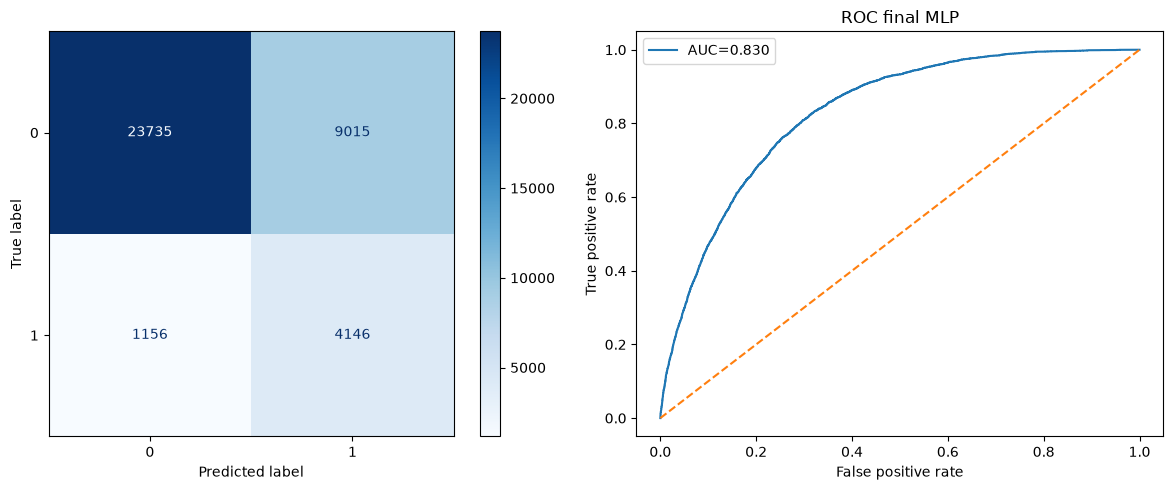

,BMI,GenHlth,MentHlth,PhysHlth,Age,Education,Income,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex,true,pred,probability_1
240097,64.0,5.0,0.0,30.0,12.0,5.0,4.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,1,0.976125
107201,58.0,5.0,1.0,30.0,10.0,5.0,6.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1,0.972709
169178,52.0,5.0,0.0,20.0,9.0,4.0,7.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0,1,0.970283
76469,71.0,4.0,26.0,15.0,10.0,3.0,2.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0,1,0.967586
9285,51.0,5.0,25.0,30.0,8.0,5.0,2.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0,1,0.963785
202234,40.0,5.0,30.0,20.0,10.0,6.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0,1,0.959517
35966,42.0,5.0,0.0,30.0,10.0,4.0,3.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0,1,0.957969
8696,44.0,5.0,0.0,30.0,12.0,5.0,5.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0,1,0.951853
11086,46.0,5.0,4.0,8.0,10.0,6.0,2.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1,0.951679
147512,49.0,3.0,15.0,15.0,11.0,4.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0,1,0.950499


,BMI,GenHlth,MentHlth,PhysHlth,Age,Education,Income,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex,true,pred,probability_1
220269,20.0,1.0,0.0,0.0,2.0,6.0,7.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1,0,0.007988
23247,25.0,1.0,2.0,0.0,5.0,4.0,8.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1,0,0.012436
16696,32.0,1.0,0.0,0.0,4.0,6.0,8.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1,0,0.013381
128207,27.0,1.0,0.0,0.0,8.0,4.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1,0,0.014196
229582,24.0,2.0,20.0,1.0,3.0,6.0,8.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1,0,0.016233
159654,26.0,1.0,0.0,0.0,9.0,6.0,8.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1,0,0.022188
198279,25.0,1.0,0.0,0.0,10.0,6.0,8.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1,0,0.027154
237990,27.0,3.0,2.0,1.0,4.0,6.0,8.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1,0,0.029403
59699,28.0,2.0,0.0,0.0,1.0,4.0,8.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1,0,0.029474
25761,25.0,1.0,30.0,0.0,9.0,6.0,8.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1,0,0.029960


In [17]:
final_mlp.eval(); all_logits = []
with torch.no_grad():
    for X_b, _ in test_loader: all_logits.append(final_mlp(X_b.to(device)).cpu())
logits = torch.cat(all_logits); test_score = torch.softmax(logits, 1)[:, 1].numpy(); test_pred = logits.argmax(1).numpy()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
metrics.ConfusionMatrixDisplay.from_predictions(y_test, test_pred, ax=axes[0], cmap="Blues")
fpr, tpr, _ = metrics.roc_curve(y_test, test_score); axes[1].plot(fpr, tpr, label=f"AUC={metrics.roc_auc_score(y_test, test_score):.3f}"); axes[1].plot([0,1],[0,1],"--"); axes[1].legend(); axes[1].set(title="ROC final MLP", xlabel="False positive rate", ylabel="True positive rate")
plt.tight_layout(); save_figure(FIGURE_DIR / "final_confusion_roc.png", dpi=160, bbox_inches="tight"); plt.show()
error_table = X_test_raw.copy(); error_table["true"] = y_test; error_table["pred"] = test_pred; error_table["probability_1"] = test_score
display(error_table.query("true == 0 and pred == 1").sort_values("probability_1", ascending=False).head(10))
display(error_table.query("true == 1 and pred == 0").sort_values("probability_1").head(10))

### Phân tích confusion matrix, ROC và lỗi

Confusion matrix chứa **TN=23.735, FP=9.015, FN=1.156, TP=4.146**. Từ 5.302 positive thật, model nhận đúng 4.146, tương ứng Recall **0,7820**; trong 13.161 dự đoán positive chỉ 4.146 đúng, nên Precision **0,3150**. Accuracy là 0,7327 và ROC-AUC **0,8296**, cho thấy continuous score có khả năng ranking khá dù threshold hiện tại tạo nhiều false positives.

Các FP xác suất cao thường có profile rủi ro quan sát được như HighBP/HighChol, `GenHlth` kém, BMI cao, khó đi bộ hoặc bệnh tim; tuy nhiên target vẫn bằng 0. Ngược lại, các FN xác suất rất thấp thường có HighBP/HighChol bằng 0, `GenHlth` tốt và activity cao dù target bằng 1. Chỉ có thể nói các mẫu này giống pattern của lớp đối diện trong feature space; không đủ evidence để gán một feature cụ thể là nguyên nhân lỗi.

Trong bối cảnh educational health-risk classification, FN là người có `Diabetes_binary=1` nhưng model trả 0 và đáng chú ý nếu ưu tiên sensitivity. Giảm threshold có thể giảm FN nhưng sẽ tăng FP; ROC không tự quyết định cost phù hợp hay tạo clinical threshold.

## Representation Probe: prepared input và hidden space

Probe so sánh projection 2D của prepared input `[N,21]` với learned hidden representation `[N,32]` của final MLP trên cùng 10.000 test samples. Màu dùng true class nhưng PCA không dùng label khi tìm trục.

PCA chỉ giữ hai hướng variance lớn nhất. Overlap trong 2D không chứng minh hai lớp không separable trong 21/32 chiều; ngược lại, một hình tách đẹp cũng không chứng minh generalization. Vì vậy plot phải được đọc cùng test metrics và Linear Probe.

### Mục đích của cell

`extract_hidden_dense` đặt final model ở evaluation mode, chia array thành batches 1.024 và dùng `no_grad` để trích activation sau ReLU cuối. Train/validation hidden features phục vụ Linear Probe; test chỉ lấy reproducible sample 10.000 cho PCA. Việc trích representation không cập nhật model và không làm rò test vào training.

In [18]:
def extract_hidden_dense(model, X_array, batch_size=1024):
    model.eval(); outputs = []
    loader = DataLoader(TensorDataset(torch.from_numpy(np.asarray(X_array, dtype=np.float32))), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (X_b,) in loader:
            _, hidden = model(X_b.to(device), return_hidden=True)
            outputs.append(hidden.cpu().numpy())
    return np.vstack(outputs)

H_train = extract_hidden_dense(final_mlp, X_train)
H_val = extract_hidden_dense(final_mlp, X_val)
rng = np.random.default_rng(RANDOM_STATE); probe_idx = rng.choice(len(X_test), size=min(10_000, len(X_test)), replace=False)
H_probe = extract_hidden_dense(final_mlp, X_test[probe_idx])
print("Input/hidden shapes:", X_test[probe_idx].shape, H_probe.shape)

Input/hidden shapes: (10000, 21) (10000, 32)


### Phân tích kết quả

Output xác nhận sample input có shape **(10.000,21)** và hidden output **(10.000,32)**, đúng final deeper architecture. Mỗi sample đã được biến đổi từ 21 biến có ngữ nghĩa trực tiếp sang 32 tọa độ phân tán. Một chiều hidden đơn lẻ không được diễn giải như “neuron huyết áp”; ý nghĩa nằm ở tổ hợp activation của toàn vector.

### Mục đích của cell

Cell fit PCA riêng cho prepared input và hidden representation rồi scatter cùng true labels. Hai PCA có hệ trục riêng, vì vậy không so tọa độ PC1/PC2 theo trị số tuyệt đối; so sánh hợp lý nằm ở mức độ overlap, spread và cấu trúc lớp trong từng space.

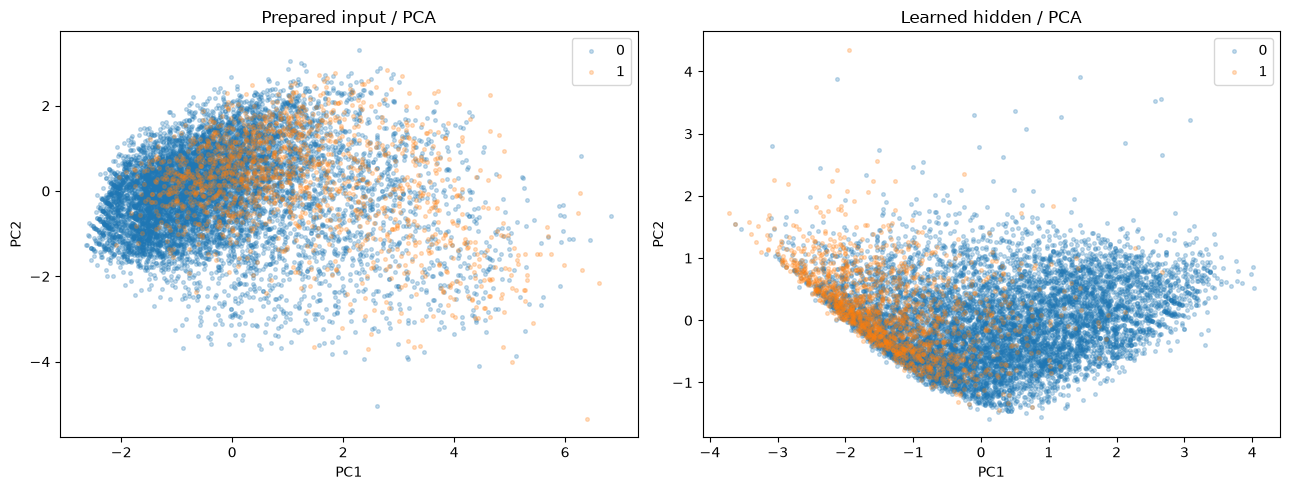

In [19]:
input_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_test[probe_idx])
hidden_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(H_probe)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, color in [(0, "tab:blue"), (1, "tab:orange")]:
    mask = y_test.to_numpy()[probe_idx] == label
    axes[0].scatter(input_2d[mask,0], input_2d[mask,1], s=7, alpha=.25, c=color, label=str(label))
    axes[1].scatter(hidden_2d[mask,0], hidden_2d[mask,1], s=7, alpha=.25, c=color, label=str(label))
axes[0].set_title("Prepared input / PCA"); axes[1].set_title("Learned hidden / PCA")
for ax in axes: ax.legend(); ax.set(xlabel="PC1", ylabel="PC2")
plt.tight_layout(); save_figure(FIGURE_DIR / "input_vs_hidden_pca.png", dpi=160, bbox_inches="tight"); plt.show()

### Phân tích PCA thực tế

Prepared-input PCA tạo một đám mây rộng với hai lớp chồng lấn mạnh; lớp 1 có xu hướng dịch sang vùng PC1 dương nhưng không hình thành cluster riêng. Hidden PCA tạo cấu trúc hình nêm rõ hơn: nhiều điểm lớp 1 tập trung về phía PC1 âm/thấp, còn lớp 0 trải rộng hơn về phía dương. Tuy vậy vùng trung tâm vẫn có overlap dày đặc và có outliers của cả hai lớp.

Như vậy MLP đã **tái cấu trúc** geometry của dữ liệu và tạo directional organization rõ hơn, nhưng visual evidence không hỗ trợ kết luận hai lớp đã được tách sạch. AUC/F1 và Linear Probe mới định lượng liệu cấu trúc đó có hữu ích hay không.

## Linear Probe cho learned representation

MLP được đóng băng; cùng một Logistic Regression cân bằng được fit trên (A) prepared input và (B) hidden representation. Probe chỉ dùng train/validation, không dùng test. Nó đo target có dễ dự đoán bằng boundary tuyến tính hơn sau transformation hay không; nó không giải thích causal effect hoặc semantic của từng hidden neuron.

### Mục đích của cell

Cell tạo hai phép đo đối chứng với cùng estimator và evaluation protocol. Input probe dùng 21 prepared features; hidden probe dùng output 32 chiều của frozen final MLP. Vì weight MLP không đổi và probe chỉ fit train, khác biệt validation phản ánh tính linear-separable của representation tốt hơn là một vòng fine-tuning mới.

In [20]:
probe_rows = []
for representation, train_features, val_features in [("Prepared input", X_train, X_val), ("Frozen hidden", H_train, H_val)]:
    probe = LogisticRegression(max_iter=1_000, class_weight="balanced", random_state=RANDOM_STATE)
    probe.fit(train_features, y_train)
    pred = probe.predict(val_features); score = probe.predict_proba(val_features)[:, 1]
    probe_rows.append({"representation": representation, **classification_metrics(y_val, pred, score)})
probe_results = pd.DataFrame(probe_rows)
display(probe_results)

,representation,accuracy,precision,recall,f1,roc_auc
0,Prepared input,0.730185,0.309522,0.760845,0.440033,0.821494
1,Frozen hidden,0.717860,0.304504,0.798189,0.440833,0.828577


### Phân tích Linear Probe

Prepared-input probe đạt F1 **0,4400**, ROC-AUC **0,8215**, Recall 0,7608. Hidden probe đạt F1 **0,4408** — chỉ tăng **0,0008** — và AUC **0,8286**, tăng 0,0071; Recall tăng lên **0,7982**, nhưng Accuracy giảm từ 0,7302 xuống 0,7179 và Precision giảm từ 0,3095 xuống 0,3045.

Kết quả cung cấp evidence vừa phải rằng hidden space cải thiện ranking và khả năng thu hồi positive bằng boundary tuyến tính, nhưng lợi ích F1 gần như không đáng kể và đi kèm nhiều false positives hơn. Vì vậy không nên gọi representation “tốt hơn toàn diện”; nó thay đổi trade-off theo hướng sensitivity.

## OPTIONAL — chẩn đoán gradient và ReLU activation

Diagnostic này nhằm quan sát gradient norm và tỷ lệ activation bằng 0 trên một batch, không phải metric chất lượng model. Activation 0 có thể chỉ là hành vi bình thường của ReLU; chỉ chuỗi quan sát theo layer/epoch mới có thể gợi ý dead neurons hoặc gradient instability.

### Mục đích của cell

Khi flag được bật, cell clone final model, chạy đúng một forward/backward batch và không gọi `optimizer.step`, nên không sửa artifact đã chọn. Ở full run hiện tại flag vẫn tắt; vì vậy không có gradient/activation values thật để diễn giải.

In [21]:
if RUN_OPTIONAL_DIAGNOSTICS:
    diagnostic_model = copy.deepcopy(final_mlp).to(device).train()
    X_b, y_b = next(iter(train_loader)); X_b, y_b = X_b.to(device), y_b.to(device)
    diagnostic_model.zero_grad(); logits, hidden = diagnostic_model(X_b, return_hidden=True)
    nn.CrossEntropyLoss(weight=class_weights.to(device))(logits, y_b).backward()
    display(pd.DataFrame([{"parameter": name, "gradient_norm": parameter.grad.norm().item()} for name, parameter in diagnostic_model.named_parameters() if parameter.grad is not None]))
    print("Tỷ lệ hidden activation bằng 0:", (hidden == 0).float().mean().item())
else:
    print("Bỏ qua diagnostics; đặt RUN_OPTIONAL_DIAGNOSTICS=True nếu muốn chạy.")

Bỏ qua diagnostics; đặt RUN_OPTIONAL_DIAGNOSTICS=True nếu muốn chạy.


### Phân tích kết quả

Output ghi rõ diagnostic đã được **bỏ qua**. Do không có gradient norm hay zero-activation fraction, notebook không đưa ra kết luận về vanishing/exploding gradient hoặc dead ReLU. Đây là giới hạn có chủ ý, không phải missing final metric.

### Mục đích của cell

Cell lưu validation baselines, bảng MLP experiments, final four-model comparison, histories, selected PyTorch state và fitted preprocessor. Metadata checkpoint ghi input dimension, hidden dimensions, output dimension, experiment và criterion lựa chọn; nhờ đó kết quả có thể được tái sử dụng mà không train lại.

In [22]:
if QUICK_MODE:
    print("QUICK_MODE: không lưu result/model artifact final.")
else:
    baseline_val_results.to_csv(RESULT_DIR / "diabetes_baseline_validation.csv", index=False)
    mlp_experiment_results.to_csv(RESULT_DIR / "diabetes_mlp_experiments.csv", index=False)
    model_comparison.to_csv(RESULT_DIR / "diabetes_model_comparison.csv", index=False)
    pd.concat([h.assign(experiment=name) for name, h in mlp_histories.items()], ignore_index=True).to_csv(RESULT_DIR / "diabetes_training_history.csv", index=False)
    torch.save({"model_state": final_mlp.state_dict(), "input_dim": X_train.shape[1], "hidden_dims": list(final_mlp.hidden_dims), "output_dim": 2, "selected_by": "validation_f1", "experiment": best_name}, MODEL_DIR / "final_mlp.pt")
    joblib.dump(preprocessor, MODEL_DIR / "preprocessor.joblib")
    print("Đã lưu kết quả thật vào", RESULT_DIR)


Đã lưu kết quả thật vào E:\WINDOW\Project\intelligent-system-assignment-01\results\assignment03


### Phân tích kết quả

Vì `QUICK_MODE=False`, output xác nhận result/model artifacts thật đã được lưu vào `results/assignment03` và `models/assignment03/diabetes`. Preprocessor đi cùng model là bắt buộc: inference mới phải dùng `transform`, không được refit scaler trên dữ liệu mới.

### Mục đích của cell

Cell kiểm tra vòng đời artifact bằng cách load checkpoint/preprocessor, dựng lại đúng MLP `21→64→32→2`, nạp `state_dict`, chuyển sang evaluation mode và inference hai test rows. Đây là serialization check, không retrain và không dùng kết quả hai rows để tuning.

In [23]:
if QUICK_MODE:
    print("QUICK_MODE: bỏ qua reload vì final artifact không được lưu.")
else:
    checkpoint = torch.load(MODEL_DIR / "final_mlp.pt", map_location=device)
    reloaded_model = MLP(checkpoint["input_dim"], checkpoint["hidden_dims"], checkpoint["output_dim"]).to(device)
    reloaded_model.load_state_dict(checkpoint["model_state"])
    reloaded_model.eval()
    loaded_preprocessor = joblib.load(MODEL_DIR / "preprocessor.joblib")
    with torch.no_grad():
        reload_input = loaded_preprocessor.transform(X_test_raw.iloc[:2]).astype("float32")
        reload_logits = reloaded_model(torch.from_numpy(reload_input).to(device))
    print("Reload output shape:", reload_logits.shape)


Reload output shape: torch.Size([2, 2])


### Phân tích kết quả

Reload thành công và trả logits shape **[2,2]**: hai samples, mỗi sample có hai raw class scores. Điều này xác nhận architecture metadata, state dictionary và preprocessing artifact tương thích sau khi lưu.

### Mục đích của cell

Cell tạo summary trực tiếp từ `model_comparison` thay vì chép metric thủ công. Nó lấy model F1 cao nhất, final MLP và traditional baseline tốt nhất, rồi hiển thị performance–cost bằng values đã tính. Cell chỉ đọc bảng hiện có, không tạo metric hoặc thay đổi model.

In [24]:
best_overall = model_comparison.sort_values("f1", ascending=False).iloc[0]
mlp_row = model_comparison.loc[model_comparison["learned_representation"]].iloc[0]
best_traditional = model_comparison.loc[~model_comparison["learned_representation"]].sort_values("f1", ascending=False).iloc[0]
display(Markdown(f"""## Kết luận dựa trên kết quả đã chạy

- Model có test F1 cao nhất: **{best_overall['model']}**, F1={best_overall['f1']:.4f}.
- Final MLP có F1={mlp_row['f1']:.4f}, so với traditional tốt nhất {best_traditional['model']} có F1={best_traditional['f1']:.4f}.
- MLP mất {mlp_row['training_seconds']:.1f}s và có {int(mlp_row['parameter_count']):,} trainable parameters.
- Cần kết hợp PCA, linear probe, false-negative cost và training time trước khi kết luận Deep Learning có đáng dùng hay không.
"""))

## Kết luận dựa trên kết quả đã chạy

- Model có test F1 cao nhất: **Random Forest**, F1=0.4593.
- Final MLP có F1=0.4491, so với traditional tốt nhất Random Forest có F1=0.4593.
- MLP mất 134.0s và có 3,554 trainable parameters.
- Cần kết hợp PCA, linear probe, false-negative cost và training time trước khi kết luận Deep Learning có đáng dùng hay không.


## Kết luận khoa học và giới hạn

**Kết luận chính.** Random Forest là model có test F1 cao nhất (**0,4593**) và train nhanh hơn final MLP khoảng 7,3 lần. Final deeper MLP (`21→64→32→2`, Adam 1e-3, 3.554 parameters, best epoch 15) đạt F1 **0,4491**, thấp hơn Forest 0,0102 nhưng có Recall **0,7820** và AUC **0,8296**, cao hơn Forest. So với Logistic Regression, MLP chỉ tăng F1 0,0054 nhưng đắt hơn khoảng 385 lần. Vì vậy neural network không thắng rõ ràng về cost–performance; giá trị bổ sung nằm ở sensitivity và khả năng nghiên cứu learned representation.

Thêm hidden layer chỉ cải thiện validation F1 0,0043 so với baseline MLP, trong khi baseline có loss/AUC hơi tốt hơn và ít parameters hơn. Giảm learning rate từ 1e-3 xuống 3e-4 làm best epoch dịch từ 15 sang 23 và tăng runtime, nhưng không cải thiện validation F1. Training curves cho thấy convergence nhanh rồi plateau, với mild train–validation gap chứ không có overfitting nghiêm trọng.

Hidden PCA có cấu trúc định hướng rõ hơn prepared input nhưng hai lớp vẫn overlap mạnh. Linear Probe củng cố một kết luận thận trọng: hidden space tăng AUC 0,0071 và Recall 0,0373, song F1 chỉ tăng 0,0008 và Precision/Accuracy giảm.

**Giới hạn.** BRFSS là dữ liệu khảo sát quan sát và có thể tự báo cáo; kết quả không mang ý nghĩa nhân quả hay chẩn đoán. Lớp dương chỉ chiếm 13,93%, threshold chịu ảnh hưởng của class weighting. Experiment chỉ khảo sát hai architecture, hai learning rates, một split seed 42 và CPU-only timing. Hidden dimensions là biểu diễn phân tán, không trực tiếp human-interpretable; PCA 2D và Linear Probe chỉ là hai phép kiểm tra hạn chế.

## Hồ sơ thực nghiệm đã hoàn tất

- [x] `QUICK_MODE=False`; full BRFSS 253.680 rows
- [x] Seed 42 và stratified 70/15/15 split
- [x] StandardScaler fit train-only; validation/test chỉ transform
- [x] Ba traditional baselines và ba MLP experiments
- [x] Final MLP chọn bằng validation F1 trước khi mở test
- [x] Confusion matrix, ROC, error analysis, PCA và Linear Probe
- [x] Model/preprocessor/results đã lưu và reload thành công

### Những câu hỏi cần bảo vệ

Kết quả không chứng minh MLP luôn tốt hơn traditional ML. Random Forest thắng F1; MLP ưu tiên Recall và tạo hidden representation có ranking tốt hơn nhẹ. Nếu triển khai trong bối cảnh thật, threshold/cost của FP–FN, calibration, external validation và đánh giá fairness cần được xác định trước khi mô hình có thể hỗ trợ bất kỳ quyết định sức khỏe nào.